Q1 - Exploratory data analysis (7 points)
Load the data2022.csv in variable orig_data using pandas.read_csv with na_filter=False option, and perform the following analysis.

1. How many materials are there in this dataset? (1 point)
2. How many elements are there in this data set? (1 point)
3. How many unique formulae are there? (1 point)
4. Count the number of materials where each element is present. Sort this count. Create a barplot showing the number of materials with the top 10 most common elements in this data set. (4 points)
- Hint: When dealing with formula, you may use pymatgen.core.Composition to speed up the process. For example, the following code snippet shows the use of Composition to process formula. For more usage, you may visit https://matgenb.materialsvirtuallab.org/2013/01/01/Basic-functionality.html

In [1]:
import pandas as pd
import numpy as np

url="https://materialsvirtuallab.github.io/nano281/assets/data2022.csv"
orig_data=pd.read_csv(url)

orig_data.head()

,Unnamed: 0,task_id,formula,formation_energy_per_atom,e_above_hull,band_gap,has_bandstructure
0,297,mp-570140,AuBr,-0.125181,0.011579,1.9716,True
1,573,mp-1206190,ZnI6,0.387945,0.652470,0.1076,False
2,579,mp-1208424,TeBr4,-0.390060,0.000000,2.5202,False
3,738,mp-570480,TcBr4,-0.404404,0.000000,0.6025,True
4,880,mp-1064459,PBr,1.067789,1.327882,0.0000,False


1. How many materials are there in this dataset?

In [2]:
print(f"Number of Materials:{len(orig_data)}")


Number of Materials:681


2. How many elements are in the dataset?

In [3]:
from pymatgen.core import Composition

elements=set()
for formula in orig_data['formula']:
    comp=Composition(formula)
    for element in comp.elements:
        elements.add(str(element))
num_unique_elements= len(elements)
print(f"Number of Elements:{num_unique_elements}")



Number of Elements:80


3. How many unique formula are there?

In [4]:
unique_formulas=orig_data['formula'].unique()
print(f"Number of Unique Formulae:{len(unique_formulas)}")

Number of Unique Formulae:392


4. Count the number of materials where each element is present. Sort this count. Create a barplot showing the number of materials with the top 10 most common elements in this data set. (4 points)

[('Br', 204), ('I', 190), ('W', 13), ('In', 11), ('Te', 10), ('Bi', 10), ('Nb', 10), ('Zr', 10), ('Sm', 10), ('Ti', 9)]


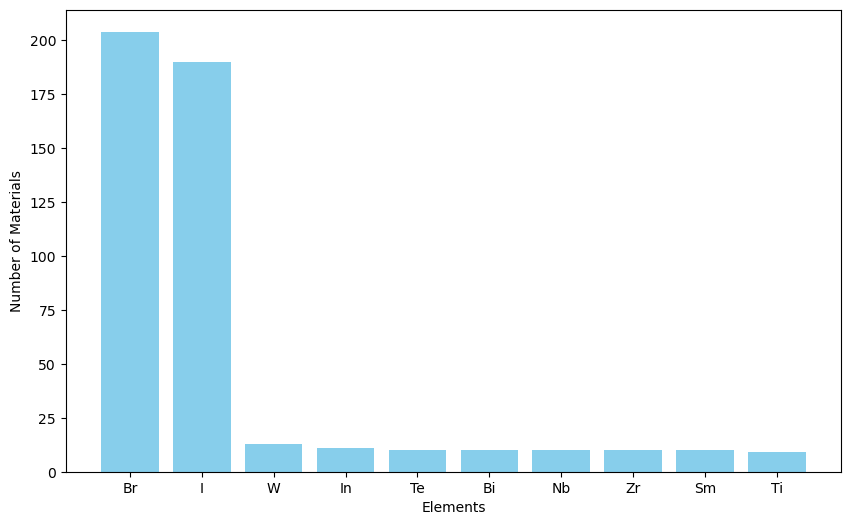

In [5]:
import collections
from matplotlib import pyplot as plt

element_counts=collections.Counter()
for formula in unique_formulas:
    comp=Composition(formula)
    for element in comp.elements:
        element_counts[str(element)]+=1

sorted_counts=element_counts.most_common()
top_10_elements=sorted_counts[:10]

#Creat bar plot
elements_for_plot=[x[0] for x in top_10_elements]
counts_for_plot=[x[1] for x in top_10_elements]

plt.figure(figsize=(10,6))
plt.bar(elements_for_plot, counts_for_plot, color='skyblue')
plt.xlabel('Elements')
plt.ylabel('Number of Materials')
print(top_10_elements)


Q2 - Data cleaning and feature computations (24 points)
- About 80% of the effort in ML modelling is in data processing. The goal is to develop ML models to predict the formation energy per atom and band gap of the material from the formula. To do that, we will first convert the formula to numeric vectors (descriptors) for model inputs. For data filtering steps, note that you should use the filtered data after each filtering step henceforth.

1. From Q1.3, we note that the number of materials is greater than the number of formulae, i.e., there can be more than 1 polymorph present per formula. We do not expect the compositional features to be able to predict multiple values of the same property for the same formula. Filter the data to remove duplicate formulae, keeping only the row with the lowest formation energy per atom for each formula. How many materials are left? (2 points)
2. Positive formation energies are often a sign that a calculation is poorly converged. Filter the data to remove rows with positive formation energies as well. How many materials are left? (2 point)
3. Download and load the element property data file in variable element_data using pandas by setting index_col=0 in pandas.read_csv function. How many NaN (Not a Number) are there in each column? (1 point)
4. Compute the mean values for each column, ignoring the NaNs. For each column, fill the NaN with the mean value of that column. This is a common data imputation technique. (2 points)
5. Compute the composition-averaged AtomicRadius for all materials and store the results in variable atomic_radius. For example, the composition-averaged AtomicRadius for Li2O can be computed as (2 * 1.45 + 0.6) / 3, where 1.45 is the AtomicRadius for Li and 0.6 is the AtomicRadius for O. Hint: Read the Pandas documentation on indexing. E.g., element_data.loc["Fe"]["AtomicRadius"] gives you the atomic radius for Fe. (5 points)
6. Compute the composition-averaged properties for all properties in element_data and for all materials. Store the results in the variable average_properties. average_properties should have a dimension of (n, 11) where n is the number of materials and 11 is the number of properties. (5 points)
7. Similar to the previous computations of average properties, compute the maximum properties and minimum properties for all properties and all materials, and store them in variables max_properties and min_properties respectively. Both variables should have dimension (n, 11). (5 points)
8. Concatenate average_properties, max_properties and min_properties, and store the result in variable design_matrix with dimension (n, 33). (2 point)

1. From Q1.3, we note that the number of materials is greater than the number of formulae, i.e., there can be more than 1 polymorph present per formula. We do not expect the compositional features to be able to predict multiple values of the same property for the same formula. Filter the data to remove duplicate formulae, keeping only the row with the lowest formation energy per atom for each formula. How many materials are left? 

In [6]:
ranked_data=orig_data.sort_values("formation_energy_per_atom")
filtered_data=ranked_data.drop_duplicates(subset=['formula'], keep='first')
print(f"Number of Materials after removing duplicates: {len(filtered_data)}")


Number of Materials after removing duplicates: 392


2. Positive formation energies are often a sign that a calculation is poorly converged. Filter the data to remove rows with positive formation energies as well. How many materials are left? (2 point)

In [7]:
materials_data=filtered_data[filtered_data['formation_energy_per_atom'] <= 0].copy()
print(f"Number of Materials after removing positive formation energies: {len(materials_data)}")


Number of Materials after removing positive formation energies: 338


3. Download and load the element property data file in variable element_data using pandas by setting index_col=0 in pandas.read_csv function. How many NaN (Not a Number) are there in each column? (1 point)

In [8]:
url2="https://materialsvirtuallab.github.io/nano281/assets/element_properties.csv"
element_data=pd.read_csv(url2, index_col=0)
element_data.head()

,AtomicRadius,AtomicVolume,AtomicWeight,BoilingT,CovalentRadius,Density,ElectronAffinity,Electronegativity,FirstIonizationEnergy,HeatCapacityMass,SecondIonizationEnergy
H,0.25,18618.051940,1.007940,20.13,31,0.0899,72.8,2.20,13.598443,14.304,NaN
He,NaN,37236.035560,4.002602,4.07,28,0.1785,0.0,NaN,24.587387,5.130,54.41776
Li,1.45,21.544058,6.941000,1615.00,128,535.0000,59.6,0.98,5.391719,3.582,75.64000
Be,1.05,8.098176,9.012182,2743.00,96,1848.0000,0.0,1.57,9.322700,1.825,18.21114
B,0.85,7.297767,10.811000,4273.00,84,2460.0000,26.7,2.04,8.298020,1.026,25.15480


In [9]:
# Count number of NaNs in each column
print("NaN counts in each column:")
print(element_data.isna().sum())

NaN counts in each column:
AtomicRadius               7
AtomicVolume               2
AtomicWeight               0
BoilingT                   2
CovalentRadius             0
Density                    2
ElectronAffinity           9
Electronegativity          4
FirstIonizationEnergy      1
HeatCapacityMass          10
SecondIonizationEnergy    12
dtype: int64


4. Compute the mean values for each column, ignoring the NaNs. For each column, fill the NaN with the mean value of that column. This is a common data imputation technique. (2 points)

In [10]:
#Compute the mean values for each column, ignoring the NaNs
mean_values = element_data.mean()
mean_values

AtomicRadius                 1.500682
AtomicVolume              3426.442121
AtomicWeight               116.153896
BoilingT                  2549.858065
CovalentRadius             151.810526
Density                   7489.235725
ElectronAffinity            76.162209
Electronegativity            1.747033
FirstIonizationEnergy        8.094711
HeatCapacityMass             0.635447
SecondIonizationEnergy      18.947504
dtype: float64

In [11]:
#Fill the NaNs with the mean values
element_data = element_data.fillna(mean_values)

#Print the first few rows of the imputed DataFrame
element_data.head()


,AtomicRadius,AtomicVolume,AtomicWeight,BoilingT,CovalentRadius,Density,ElectronAffinity,Electronegativity,FirstIonizationEnergy,HeatCapacityMass,SecondIonizationEnergy
H,0.250000,18618.051940,1.007940,20.13,31,0.0899,72.8,2.200000,13.598443,14.304,18.947504
He,1.500682,37236.035560,4.002602,4.07,28,0.1785,0.0,1.747033,24.587387,5.130,54.417760
Li,1.450000,21.544058,6.941000,1615.00,128,535.0000,59.6,0.980000,5.391719,3.582,75.640000
Be,1.050000,8.098176,9.012182,2743.00,96,1848.0000,0.0,1.570000,9.322700,1.825,18.211140
B,0.850000,7.297767,10.811000,4273.00,84,2460.0000,26.7,2.040000,8.298020,1.026,25.154800


5. Compute the composition-averaged AtomicRadius for all materials and store the results in variable atomic_radius. For example, the composition-averaged AtomicRadius for Li2O can be computed as (2 * 1.45 + 0.6) / 3, where 1.45 is the AtomicRadius for Li and 0.6 is the AtomicRadius for O. Hint: Read the Pandas documentation on indexing. E.g., element_data.loc["Fe"]["AtomicRadius"] gives you the atomic radius for Fe. (5 points)

In [12]:
atomic_radius=[]

def get_avg_radius(formula):
    comp=Composition(formula)
    total_atoms=comp.num_atoms
    radius_sum=0
    for element, amount in comp.items():
        radius=element_data.loc[str(element)]["AtomicRadius"]
        radius_sum+=radius*amount
    return radius_sum/total_atoms

materials_data['atomic_radius'] = materials_data['formula'].apply(get_avg_radius)

materials_data.head()


,Unnamed: 0,task_id,formula,formation_energy_per_atom,e_above_hull,band_gap,has_bandstructure,atomic_radius
191,29313,mp-27456,BaBr2,-2.227832,0.0,4.3731,True,1.483333
475,80856,mp-567744,SrBr2,-2.156160,0.0,4.4697,True,1.433333
219,35022,mp-1071541,YbBr2,-2.109686,0.0,4.3169,False,1.350000
414,70294,mp-27972,AcBr3,-2.098107,0.0,4.1045,True,1.350000
304,51723,mp-22888,CaBr2,-2.052632,0.0,4.5304,True,1.366667


6. Compute the composition-averaged properties for all properties in element_data and for all materials. Store the results in the variable average_properties. average_properties should have a dimension of (n, 11) where n is the number of materials and 11 is the number of properties. (5 points)

In [13]:
#define a function to compute the composition-averaged properties for all properties in element_data and for all materials
def get_avg_properties(materials_data,col):
    temp=[]
    for formula in materials_data['formula']:
        comp=Composition(formula)
        total_atoms=comp.num_atoms
        prop_sum=0 
        for element, amount in comp.items():
            props=element_data.loc[str(element)][col]
            prop_sum+= props*amount
        #Calculate average and add to list
        prop_avg=prop_sum/total_atoms
        temp.append(prop_avg)
    return temp

# List of columns to calculate
columns_to_calculate = element_data.columns
# Create an empty DataFrame to store the results
average_properties = pd.DataFrame()
# Apply the function to each column
for col in columns_to_calculate:
    average_properties[col] = get_avg_properties(materials_data, col)

#average_properties=average_properties.set_index(materials_data['formula'])

print("Shape of average_properties:", average_properties.shape)
average_properties.head()

    

Shape of average_properties: (338, 11)


,AtomicRadius,AtomicVolume,AtomicWeight,BoilingT,CovalentRadius,Density,ElectronAffinity,Electronegativity,FirstIonizationEnergy,HeatCapacityMass,SecondIonizationEnergy
0,1.483333,50.008311,99.045000,935.666667,151.666667,3250.000000,221.050000,2.270000,9.613088,0.384000,17.728610
1,1.433333,46.792927,82.476000,773.000000,145.000000,2956.666667,218.076667,2.290000,9.774150,0.418000,18.070700
2,1.350000,42.931774,110.954000,711.000000,142.333333,4270.000000,233.066667,2.393333,9.960587,0.367667,18.452667
3,1.350000,41.254141,116.678000,1117.250000,143.750000,4857.500000,262.490552,2.495000,10.152850,0.385500,19.130750
4,1.366667,42.664279,66.628667,807.000000,138.666667,2596.666667,217.190000,2.306667,9.913587,0.531667,18.351240


7. Similar to the previous computations of average properties, compute the maximum properties and minimum properties for all properties and all materials, and store them in variables max_properties and min_properties respectively. Both variables should have dimension (n, 11). (5 points)

In [14]:
def get_max_min_properties(materials_data):
    # Create an empty list to store the max property values for each formula
    max_properties = []
    min_properties = []

    # Loop through each formula
    for formula in materials_data['formula']:
        # Create a Composition object to extract elements and their amounts
        comp = Composition(formula)
        max_values = {}
        min_values = {}
        for col in element_data.columns:
            max_value = float('-inf')
            min_value = float('inf')
            for element, amount in comp.items():
                prop_value = element_data.loc[str(element)][col]
                if prop_value > max_value:
                    max_value = prop_value
                if prop_value < min_value:
                    min_value = prop_value

            max_values[col] = max_value
            min_values[col] = min_value

        max_properties.append(max_values)
        min_properties.append(min_values)

    return max_properties, min_properties

max_properties, min_properties = get_max_min_properties(materials_data)
max_properties=pd.DataFrame(max_properties)
min_properties=pd.DataFrame(min_properties)
max_properties.columns=["max_"+col for col in element_data.columns]
min_properties.columns=["min_"+col for col in element_data.columns]
max_properties.head()


,max_AtomicRadius,max_AtomicVolume,max_AtomicWeight,max_BoilingT,max_CovalentRadius,max_Density,max_ElectronAffinity,max_Electronegativity,max_FirstIonizationEnergy,max_HeatCapacityMass,max_SecondIonizationEnergy
0,2.15,64.969282,137.327,2143.0,215.0,3510.0,324.6,2.96,11.8138,0.474,21.591
1,2.00,55.323131,87.620,1655.0,195.0,3120.0,324.6,2.96,11.8138,0.474,21.591
2,1.75,43.739672,173.054,1469.0,187.0,6570.0,324.6,2.96,11.8138,0.474,21.591
3,1.95,42.527825,227.000,3473.0,215.0,10070.0,324.6,2.96,11.8138,0.474,21.591
4,1.80,42.937187,79.904,1757.0,176.0,3120.0,324.6,2.96,11.8138,0.647,21.591


In [15]:
min_properties.head()

,min_AtomicRadius,min_AtomicVolume,min_AtomicWeight,min_BoilingT,min_CovalentRadius,min_Density,min_ElectronAffinity,min_Electronegativity,min_FirstIonizationEnergy,min_HeatCapacityMass,min_SecondIonizationEnergy
0,1.15,42.527825,79.904,332.0,120.0,3120.0,13.950000,0.89,5.211664,0.204,10.00383
1,1.15,42.527825,79.904,332.0,120.0,2630.0,5.030000,0.95,5.694850,0.306,11.03010
2,1.15,42.527825,79.904,332.0,120.0,3120.0,50.000000,1.26,6.254160,0.155,12.17600
3,1.15,37.433086,79.904,332.0,120.0,3120.0,76.162209,1.10,5.170000,0.120,11.75000
4,1.15,42.527825,40.078,332.0,120.0,1550.0,2.370000,1.00,6.113160,0.474,11.87172


In [16]:
print("Shape of max_properties:", max_properties.shape)
print("Shape of min_properties:", min_properties.shape)


Shape of max_properties: (338, 11)
Shape of min_properties: (338, 11)


8. Concatenate average_properties, max_properties and min_properties, and store the result in variable design_matrix with dimension (n, 33). (2 point)

In [17]:
design_matrix=pd.concat([average_properties,max_properties,min_properties],axis=1)

#Check the shape of the design matrix
print("Shape of design_matrix:", design_matrix.shape)
design_matrix.head()


Shape of design_matrix: (338, 33)


,AtomicRadius,AtomicVolume,AtomicWeight,BoilingT,CovalentRadius,Density,ElectronAffinity,Electronegativity,FirstIonizationEnergy,HeatCapacityMass,...,min_AtomicVolume,min_AtomicWeight,min_BoilingT,min_CovalentRadius,min_Density,min_ElectronAffinity,min_Electronegativity,min_FirstIonizationEnergy,min_HeatCapacityMass,min_SecondIonizationEnergy
0,1.483333,50.008311,99.045000,935.666667,151.666667,3250.000000,221.050000,2.270000,9.613088,0.384000,...,42.527825,79.904,332.0,120.0,3120.0,13.950000,0.89,5.211664,0.204,10.00383
1,1.433333,46.792927,82.476000,773.000000,145.000000,2956.666667,218.076667,2.290000,9.774150,0.418000,...,42.527825,79.904,332.0,120.0,2630.0,5.030000,0.95,5.694850,0.306,11.03010
2,1.350000,42.931774,110.954000,711.000000,142.333333,4270.000000,233.066667,2.393333,9.960587,0.367667,...,42.527825,79.904,332.0,120.0,3120.0,50.000000,1.26,6.254160,0.155,12.17600
3,1.350000,41.254141,116.678000,1117.250000,143.750000,4857.500000,262.490552,2.495000,10.152850,0.385500,...,37.433086,79.904,332.0,120.0,3120.0,76.162209,1.10,5.170000,0.120,11.75000
4,1.366667,42.664279,66.628667,807.000000,138.666667,2596.666667,217.190000,2.306667,9.913587,0.531667,...,42.527825,40.078,332.0,120.0,1550.0,2.370000,1.00,6.113160,0.474,11.87172


Q3 Regression and classification modeling (39 points)
- We are going to use band_gap and formation_energy_per_atom in data as the targets. To make sure the results are reproducible, set the random_state=42 in all cases where random sampling is involved, e.g., train_test_split, shuffling, etc.

1. Split the data (design_matrix as X, and targets as y) into training and test sets in the ratio 90%:10%. Store the training data in variables train_X and train_y and the test data as variables test_X and test_y. (2 points)
2. Compute the mean and standard deviation of columns in train_X. Both of them should be length 33 vectors. Use them to normalize train_X and test_X, so that each column has a mean of 0 and standard deviation of 1. Store the normalized design matrices to norm_train_X, norm_test_X. (4 points)
- Note that from here out, all model training and validation should be done with the training split. The test split is only used for calculating a final model performance assessment in part 5. It is not used for any other purposes. You should be using proper ML best practices such as cross-validation in fitting the model. In all cases, the loss function you use should be the mean squared error. You need to figure out where and how to specify the loss function in the training.

1. Train a simple linear regression model to predict formation_energy_per_atom. What is the CV score of your model? (4 points)
2. Train a Ridge regression model and a LASSO regression model for the formation_energy_per_atom. You need to search for an optimal value of alpha for each model. To help you, try the following ranges of alpha: ridge (0.1-10), lasso (0.0001-0.01). You have to figure out how best to sample the range of alphas. Too dense a sampling will result in very slow searches and too sparse will result in non-optimal models. What are the CV scores of your best Ridge and Lasso models? (10 points)
3. What are the test MAE and RMSE of the best model (among all models you have fitted so far)? (2 points)
4. What are the features that do not contribute to the LASSO prediction? (4 points)
5. Let’s define band_gap < 0.001 as metallic and band_gap >= 0.001 as nonmetallic. Construct linear discriminant analysis, quadratic discriminant analysis, and logistic regression models on train data and predict the accuracy of the models on test data. (11 points)
6. What are the problems of using only the compositions to predict material properties? (2 points)

1. Split the data (design_matrix as X, and targets as y) into training and test sets in the ratio 90%:10%. Store the training data in variables train_X and train_y and the test data as variables test_X and test_y. (2 points)

In [18]:
from sklearn.model_selection import train_test_split

#Features (X) and target (y)
X = design_matrix
y = materials_data[["formation_energy_per_atom", "band_gap"]]  # target variables


#Split the data
train_X, test_X, train_y, test_y = train_test_split (X, y, test_size= 0.1, random_state=42)
print(train_X.shape)
print(test_X.shape)
print(train_y.shape)
print(test_y.shape)


(304, 33)
(34, 33)
(304, 2)
(34, 2)


In [19]:
display(train_X)
display(test_X)
display(train_y)
display(test_y)

,AtomicRadius,AtomicVolume,AtomicWeight,BoilingT,CovalentRadius,Density,ElectronAffinity,Electronegativity,FirstIonizationEnergy,HeatCapacityMass,...,min_AtomicVolume,min_AtomicWeight,min_BoilingT,min_CovalentRadius,min_Density,min_ElectronAffinity,min_Electronegativity,min_FirstIonizationEnergy,min_HeatCapacityMass,min_SecondIonizationEnergy
279,1.383333,33.559393,149.630980,1670.866667,138.000000,10323.333333,265.233333,2.533333,9.953773,0.187000,...,15.360464,126.90447,457.3,136.0,4940.0,205.300000,2.28,8.958800,0.133,18.563000
116,1.233333,34.230656,69.225000,1408.000000,133.333333,3582.333333,218.933333,2.486667,10.151907,0.490667,...,17.636317,47.86700,332.0,120.0,3120.0,7.600000,1.54,6.828120,0.474,13.575500
274,1.383333,33.725483,145.882980,2247.533333,146.666667,9710.000000,223.000000,2.560000,9.588850,0.186667,...,15.858734,126.90447,457.3,139.0,4940.0,78.600000,2.36,7.864030,0.132,16.100000
300,1.412500,28.048676,38.204750,1105.250000,135.750000,2083.500000,81.150000,1.722500,8.688126,0.885750,...,23.222293,24.30500,332.0,120.0,1738.0,0.000000,1.31,7.646235,0.474,15.035270
78,1.300000,36.707079,119.178000,1317.250000,137.500000,7452.500000,262.490552,2.560000,10.426775,0.514362,...,19.244839,79.90400,332.0,120.0,3120.0,76.162209,1.36,6.265700,0.474,18.947504
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,1.450000,35.632580,122.073313,651.533333,140.666667,6176.666667,196.800000,2.336667,9.965447,0.219667,...,21.580025,112.41100,457.3,139.0,4940.0,0.000000,1.69,8.993820,0.214,16.908310
71,1.230000,38.476002,99.621200,1240.800000,131.000000,5158.000000,259.680000,2.628000,10.816054,0.408000,...,22.268711,79.90400,332.0,120.0,3120.0,0.000000,1.30,6.825070,0.144,15.000000
106,1.500000,38.242322,115.132000,1204.000000,159.000000,5236.500000,187.300000,2.065000,8.728750,0.335000,...,33.956819,79.90400,332.0,120.0,3120.0,50.000000,1.17,5.643700,0.196,11.070000
270,1.400000,33.338700,120.076313,1383.533333,139.000000,7301.000000,214.700000,2.506667,9.746473,0.224000,...,14.698386,106.42000,457.3,139.0,4940.0,53.700000,2.20,8.336900,0.214,19.131300


,AtomicRadius,AtomicVolume,AtomicWeight,BoilingT,CovalentRadius,Density,ElectronAffinity,Electronegativity,FirstIonizationEnergy,HeatCapacityMass,...,min_AtomicVolume,min_AtomicWeight,min_BoilingT,min_CovalentRadius,min_Density,min_ElectronAffinity,min_Electronegativity,min_FirstIonizationEnergy,min_HeatCapacityMass,min_SecondIonizationEnergy
110,1.175000,36.044475,66.673385,947.000000,120.250000,3015.000000,254.075000,2.622500,10.356792,0.579750,...,16.594425,26.981539,332.0,120.0,2700.0,42.500000,1.610,5.985768,0.474,18.828550
333,1.400000,39.758135,127.136313,725.200000,138.666667,5373.333333,260.200000,2.473333,9.970707,0.210000,...,33.956689,126.904470,457.3,138.0,4940.0,190.200000,2.100,9.009600,0.202,18.600000
185,1.450000,55.056107,81.294950,489.250000,145.000000,2723.000000,255.175000,2.425000,9.904632,0.446250,...,42.527825,79.904000,332.0,120.0,1532.0,46.900000,0.820,4.177128,0.363,21.591000
76,1.230000,38.675449,82.168000,1202.000000,131.000000,3798.200000,267.900000,2.634000,10.777820,0.434800,...,23.265943,79.904000,332.0,120.0,3120.0,41.100000,1.330,6.633900,0.278,13.100000
211,1.183333,38.082977,97.226667,1248.000000,127.000000,5808.333333,283.600000,2.860000,11.155505,0.417000,...,15.858734,79.904000,332.0,120.0,3120.0,78.600000,2.360,7.864030,0.132,16.100000
199,1.216667,33.638128,114.549333,2164.000000,134.000000,8496.666667,242.600000,2.760000,10.497210,0.360000,...,15.858734,79.904000,332.0,120.0,3120.0,78.600000,2.360,7.864030,0.132,16.100000
42,1.370000,39.834080,102.047314,880.114286,144.514286,4450.371429,238.297143,2.397429,9.874626,0.386629,...,33.956819,79.904000,332.0,120.0,3120.0,50.000000,1.170,5.643700,0.196,11.070000
260,1.387500,35.425521,120.904728,1334.975000,139.750000,6817.500000,248.825000,2.565000,9.703170,0.221250,...,13.725510,102.905500,457.3,139.0,4940.0,109.700000,2.280,7.458900,0.214,18.080000
209,1.207143,34.908085,109.600000,1902.285714,132.000000,7728.571429,254.314286,2.788571,10.685294,0.376286,...,15.858734,79.904000,332.0,120.0,3120.0,78.600000,2.360,7.864030,0.132,16.100000
25,1.675000,59.187845,59.501150,682.000000,161.500000,1988.000000,186.500000,1.890000,8.077232,0.615500,...,42.527825,39.098300,332.0,120.0,856.0,48.400000,0.820,4.340663,0.474,21.591000


,formation_energy_per_atom,band_gap
667,-0.165995,1.2280
660,-1.044361,0.0000
451,-0.208133,1.9586
613,-0.118789,0.0000
449,-1.358265,0.0000
...,...,...
314,-0.592137,2.4223
188,-1.394327,4.2902
295,-1.149715,0.0000
607,-0.251194,0.9081


,formation_energy_per_atom,band_gap
606,-1.121821,4.0967
222,-0.036698,0.7144
467,-0.614054,0.0000
19,-1.370111,3.7882
662,-0.472848,0.0000
673,-0.494712,2.4659
358,-1.562431,0.0000
484,-0.287114,1.0392
34,-0.475903,0.8505
64,-1.765672,4.3102


In [20]:

print("Train shape:", train_X.shape, train_y.shape)
print("Test shape:", test_X.shape, test_y.shape)


Train shape: (304, 33) (304, 2)
Test shape: (34, 33) (34, 2)


2. Compute the mean and standard deviation of columns in train_X. Both of them should be length 33 vectors. Use them to normalize train_X and test_X, so that each column has a mean of 0 and standard deviation of 1. Store the normalized design matrices to norm_train_X, norm_test_X. (4 points)

In [21]:
from sklearn.preprocessing import StandardScaler

#create scaler and fit only on training data
scaler = StandardScaler()
scaler.fit(train_X)

means = scaler.mean_
stds = scaler.scale_
print("Mean vector shape:", scaler.mean_.shape)
print("Standard deviation vector shape:", scaler.scale_.shape)
print("First 3 means:", scaler.mean_[:3])
print("First 3 stds:", scaler.scale_[:3])

Mean vector shape: (33,)
Standard deviation vector shape: (33,)
First 3 means: [  1.3791273   99.35484941 109.02830868]
First 3 stds: [1.68208252e-01 7.51237569e+02 2.90681368e+01]


In [22]:

#transform both training and test data
norm_train_X = scaler.transform(train_X)
norm_test_X = scaler.transform(test_X)

print("Normalized train shape:", norm_train_X.shape)
print("Mean of each column in train_X (before normalization):", scaler.mean_)  # shape: (33,)
print("Standard deviation of each column in train_X:", scaler.scale_)          # shape: (33,)

Normalized train shape: (304, 33)
Mean of each column in train_X (before normalization): [1.37912730e+00 9.93548494e+01 1.09028309e+02 1.21913837e+03
 1.40623784e+02 5.36699313e+03 2.26909012e+02 2.39553176e+00
 9.73272877e+00 4.05163362e-01 1.91331574e+01 1.60674342e+00
 1.67223572e+02 1.43053113e+02 3.01562237e+03 1.65921053e+02
 8.94455592e+03 3.11157237e+02 2.82282895e+00 1.12071362e+01
 5.60332740e-01 2.12909389e+01 1.23914474e+00 2.61235755e+01
 8.37209535e+01 3.86827829e+02 1.26000000e+02 3.59466178e+03
 6.42637783e+01 1.59379934e+00 6.93304434e+00 2.35207237e-01
 1.54138347e+01]
Standard deviation of each column in train_X: [1.68208252e-01 7.51237569e+02 2.90681368e+01 4.89134171e+02
 1.65889706e+01 1.83732610e+03 4.41919508e+01 2.99007821e-01
 1.04370242e+00 5.94795679e-01 3.26983573e+00 2.75917584e-01
 1.50155215e+03 4.48595615e+01 1.38807891e+03 3.03372548e+01
 4.91186822e+03 1.46461379e+01 1.49450387e-01 7.03817708e-01
 1.16791050e+00 5.19008141e+00 1.53030544e-01 9.4899198

In [23]:
#Check means and stds after normalization
import numpy as np

# Check means and stds after normalization
print("Mean of normalized train_X:", np.mean(norm_train_X, axis=0)[:5])
print("Std of normalized train_X:", np.std(norm_train_X, axis=0)[:5])

Mean of normalized train_X: [ 1.07224171e-15  0.00000000e+00 -1.16865582e-17 -1.94289029e-16
  3.52057564e-16]
Std of normalized train_X: [1. 1. 1. 1. 1.]


- Note that from here out, all model training and validation should be done with the training split. The test split is only used for calculating a final model performance assessment in part 5. It is not used for any other purposes. You should be using proper ML best practices such as cross-validation in fitting the model. In all cases, the loss function you use should be the mean squared error. You need to figure out where and how to specify the loss function in the training.

1. Train a simple linear regression model to predict formation_energy_per_atom. What is the CV score of your model? (4 points)

In [24]:
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.linear_model import LinearRegression
import numpy as np
y_train_fe=train_y["formation_energy_per_atom"]
model=LinearRegression()
kf=KFold(n_splits=10, shuffle=True, random_state=42)
#y_pred=cross_val_predict(model, norm_train_X, y_train_fe, cv=kf)


mse_scorer=make_scorer(mean_squared_error, greater_is_better=False)
cv_scores=cross_val_score(model, norm_train_X, y_train_fe, cv=kf, scoring=mse_scorer)
mse_scores=-cv_scores
rmse_scores=np.sqrt(mse_scores)

print(f"MSE scores from 10-fold CV: {mse_scores}")
print(f"Average CV MSE score: {np.mean(mse_scores)}")


MSE scores from 10-fold CV: [0.04580464 6.36457483 8.53828654 0.03226982 0.03527782 0.11003752
 0.04970852 0.02147968 0.10794369 0.10949573]
Average CV MSE score: 1.5414878784115564


2. Train a Ridge regression model and a LASSO regression model for the formation_energy_per_atom. You need to search for an optimal value of alpha for each model. To help you, try the following ranges of alpha: ridge (0.1-10), lasso (0.0001-0.01). You have to figure out how best to sample the range of alphas. Too dense a sampling will result in very slow searches and too sparse will result in non-optimal models. What are the CV scores of your best Ridge and Lasso models? (10 points)

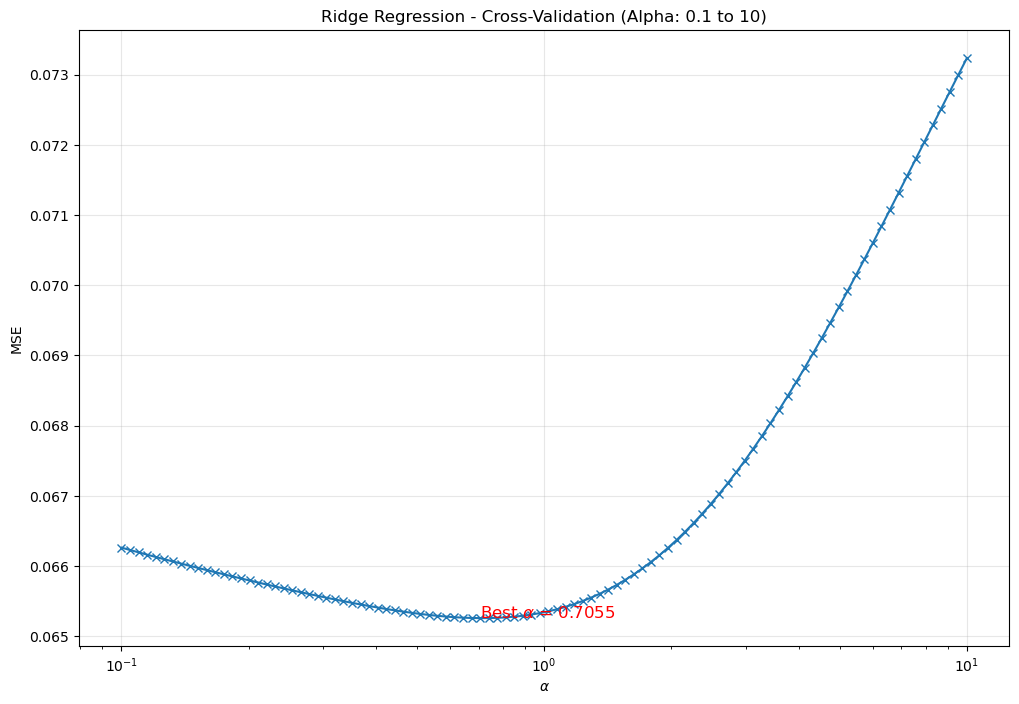

Best Ridge Alpha: 0.7054802310718644
Best Ridge CV MSE: 0.06525856351333321


In [25]:
#Train a Ridge regression model
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_validate
import numpy as np

#Target variable for training

ridge_results=[]
#Define alpha range for Ridge
ridge_alphas=np.logspace(-1, 1, 100)
kfold=KFold(n_splits=10, shuffle=True, random_state=42)
#Ridge Regression
for alpha in ridge_alphas:
    ridge=Ridge(alpha=alpha,random_state=42)
    scores=cross_validate(ridge, norm_train_X, y_train_fe, cv=kfold, scoring="neg_mean_squared_error")
    ridge_results.append([alpha,-np.mean(scores["test_score"])])


ridge_results=pd.DataFrame(ridge_results, columns=["alpha","score"])
# Plotting
plt.figure(figsize=(12, 8))
plt.plot(ridge_results["alpha"], ridge_results["score"], "-x")
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.ylabel("MSE")
plt.title("Ridge Regression - Cross-Validation (Alpha: 0.1 to 10)")
plt.grid(alpha=0.3)

# Annotate the best alpha
best_ridge_alpha = ridge_results["alpha"][ridge_results["score"].idxmin()]
plt.annotate(
    rf"Best $\alpha$ = {best_ridge_alpha:.4f}",
    (best_ridge_alpha, ridge_results["score"].min()),
    fontsize=12,
    color='red'
)
plt.show()

print(f"Best Ridge Alpha: {best_ridge_alpha}")
print(f"Best Ridge CV MSE: {ridge_results['score'].min()}")

/opt/anaconda3/envs/NANOx81-py311/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.654e+00, tolerance: 9.237e-03
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/NANOx81-py311/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.857e+00, tolerance: 8.874e-03
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/NANOx81-py311/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider

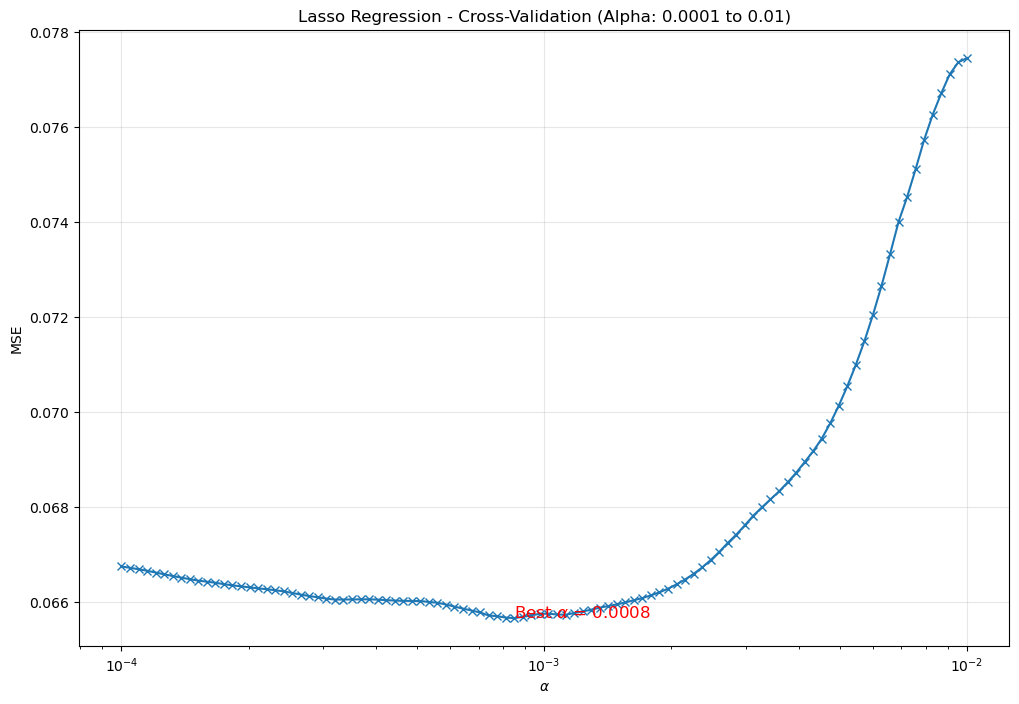

Best Lasso Alpha: 0.0008497534359086447
Best Lasso CV MSE: 0.06567114274456992


In [26]:
#train a lasso regression model and find the best alpha and CV MSE
from sklearn.linear_model import Lasso
from sklearn.model_selection import KFold, cross_validate
import numpy as np

#Target variable for training
lasso_alphas=np.logspace(-4, -2, 100)
kfold=KFold(n_splits=10, shuffle=True, random_state=42)

lasso_results=[]

#Lasso Regression
for alpha in lasso_alphas:
    lasso=Lasso(alpha=alpha,random_state=42)
    scores=cross_validate(lasso, norm_train_X, y_train_fe, cv=kfold, scoring="neg_mean_squared_error")
    lasso_results.append([alpha,-np.mean(scores["test_score"])])


lasso_results=pd.DataFrame(lasso_results, columns=["alpha","score"])
# Plotting
plt.figure(figsize=(12, 8))
plt.plot(lasso_results["alpha"], lasso_results["score"], "-x")
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.ylabel("MSE")
plt.title("Lasso Regression - Cross-Validation (Alpha: 0.0001 to 0.01)")
plt.grid(alpha=0.3)

# Annotate the best alpha
best_lasso_alpha = lasso_results["alpha"][lasso_results["score"].idxmin()]
plt.annotate(
    rf"Best $\alpha$ = {best_lasso_alpha:.4f}",
    (best_lasso_alpha, lasso_results["score"].min()),
    fontsize=12,
    color='red'
)
plt.show()

print(f"Best Lasso Alpha: {best_lasso_alpha}")
print(f"Best Lasso CV MSE: {lasso_results['score'].min()}")


3. What are the test MAE and RMSE of the best model (among all models you have fitted so far)? (2 points)

- Linear regression CV MSE: 1.5414878784115564
- Best Ridge CV MSE: 0.06525856351333321
- Best Lasso CV MSE: 0.06567137020513855
- Ridge is the best among all the models. Slight better than Lasso and much better than linear regression.


In [27]:

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
import numpy as np

# Re-fit Ridge model with optimal alpha
ridge_model = Ridge(alpha=best_ridge_alpha,random_state=42)
ridge_model.fit(norm_train_X, train_y["formation_energy_per_atom"])

# Predict on the test set
y_pred = ridge_model.predict(norm_test_X)
y_true = test_y["formation_energy_per_atom"]

# Calculate MAE
mae = mean_absolute_error(y_true, y_pred)

# Calculate RMSE
rmse=root_mean_squared_error(y_true, y_pred)

# Display results
print(f"Best Ridge Alpha: {best_ridge_alpha}")
print(f"Test MAE (Ridge): {mae}")
print(f"Test RMSE (Ridge): {rmse}")

Best Ridge Alpha: 0.7054802310718644
Test MAE (Ridge): 0.1641352083526335
Test RMSE (Ridge): 0.2222231962236474


In [28]:
#As a reference, also calculated the MAE and RMSE for the Lasso model
lasso_model = Lasso(alpha=best_lasso_alpha, random_state=42)
lasso_model.fit(norm_train_X, train_y["formation_energy_per_atom"])
y_pred_lasso = lasso_model.predict(norm_test_X)
mae_lasso = mean_absolute_error(y_true, y_pred_lasso)
rmse_lasso = root_mean_squared_error(y_true, y_pred_lasso)
print(f"Best Lasso Alpha: {best_lasso_alpha}")
print(f"Test MAE (Lasso): {mae_lasso}")
print(f"Test RMSE (Lasso): {rmse_lasso}")

Best Lasso Alpha: 0.0008497534359086447
Test MAE (Lasso): 0.1654496277474086
Test RMSE (Lasso): 0.22180449598036944


4. What are the features that do not contribute to the LASSO prediction? (4 points)

In [29]:
from sklearn.linear_model import Lasso

# Fit Lasso model with best alpha
lasso_model = Lasso(alpha=best_lasso_alpha, max_iter=10000)
lasso_model.fit(norm_train_X, train_y["formation_energy_per_atom"])

lasso_coef=lasso_model.coef_
lasso_coef


array([ 1.50248815e-02,  0.00000000e+00,  1.20597911e-01,  6.14339765e-03,
        0.00000000e+00, -1.14877456e-01,  3.01803453e-02, -8.21933573e-02,
        0.00000000e+00,  0.00000000e+00, -7.42295677e-01,  0.00000000e+00,
        1.10043225e-01, -2.45403430e-02,  2.53494935e-03, -4.85417653e-02,
        0.00000000e+00, -0.00000000e+00, -0.00000000e+00,  0.00000000e+00,
       -3.38840457e-02,  5.51060610e-01, -4.17723881e-05, -1.87427048e-01,
        3.80589644e-02, -1.19260854e-03,  8.83462472e-02, -3.15935154e-02,
        3.48018939e-02,  2.65933472e-01,  5.64876802e-02, -2.60294815e-02,
        3.83951579e-01])

In [30]:
# Get the feature names
feature_names = train_X.columns

# Create an empty list to store features with zero coefficients
zero_coeffs = []

# Loop through each coefficient
for i in range(len(lasso_coef)):
    # Check if the coefficient is zero
    if lasso_coef[i] == 0:
        # Add the feature name to the list
        zero_coeffs.append(feature_names[i])

# Print the result
print(f"Number of features with zero coefficients: {len(zero_coeffs)}")
print("Features with zero coefficients:", zero_coeffs)

Number of features with zero coefficients: 9
Features with zero coefficients: ['AtomicVolume', 'CovalentRadius', 'FirstIonizationEnergy', 'HeatCapacityMass', 'max_AtomicRadius', 'max_Density', 'max_ElectronAffinity', 'max_Electronegativity', 'max_FirstIonizationEnergy']


5. Let’s define band_gap < 0.001 as metallic and band_gap >= 0.001 as nonmetallic. Construct linear discriminant analysis, quadratic discriminant analysis, and logistic regression models on train data and predict the accuracy of the models on test data. (11 points)

In [31]:
#from sklearn.preprocessing import LabelEncoder

# Define the classification target
train_y_class = (train_y["band_gap"] < 0.001).astype(int)
test_y_class = (test_y["band_gap"] < 0.001).astype(int)

# Check distribution
print("Training class distribution:\n", train_y_class.value_counts())
print("Test class distribution:\n", test_y_class.value_counts())

Training class distribution:
 band_gap
0    208
1     96
Name: count, dtype: int64
Test class distribution:
 band_gap
0    20
1    14
Name: count, dtype: int64


In [32]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [33]:
# Initialize and fit LDA
lda = LinearDiscriminantAnalysis()
ldamodel=lda.fit(norm_train_X, train_y_class)

# Predict and evaluate
lda_preds = ldamodel.predict(norm_test_X)
lda_accuracy = accuracy_score(test_y_class, lda_preds)

print(f"LDA Accuracy: {lda_accuracy}")

LDA Accuracy: 0.6764705882352942


In [34]:
#Fit QDA
qda = QuadraticDiscriminantAnalysis()  
qda.fit(norm_train_X, train_y_class)

# Predict and evaluate
qda_preds = qda.predict(norm_test_X)
qda_accuracy = accuracy_score(test_y_class, qda_preds)

print(f"QDA Accuracy: {qda_accuracy}")



QDA Accuracy: 0.5


/opt/anaconda3/envs/NANOx81-py311/lib/python3.11/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/anaconda3/envs/NANOx81-py311/lib/python3.11/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


In [35]:
# Increase reg_param to stabilize the covariance matrix
qda_reg = QuadraticDiscriminantAnalysis(reg_param=0.1)  # You can adjust 0.1 to a higher value if needed
qda_reg.fit(norm_train_X, train_y_class)

# Predict and evaluate
qda_reg_preds = qda_reg.predict(norm_test_X)
qda_reg_accuracy = accuracy_score(test_y_class, qda_reg_preds)

print(f"QDA Accuracy with Regularization: {qda_reg_accuracy}")



QDA Accuracy with Regularization: 0.5882352941176471


In [36]:
# Initialize and fit Logistic Regression
logreg = LogisticRegression()
logreg.fit(norm_train_X, train_y_class)

# Predict and evaluate
logreg_preds = logreg.predict(norm_test_X)
logreg_accuracy = accuracy_score(test_y_class, logreg_preds)

print(f"Logistic Regression Accuracy: {logreg_accuracy}")

Logistic Regression Accuracy: 0.6470588235294118


In [37]:
print("Model Accuracy Scores:")
print(f"LDA: {lda_accuracy}")
print(f"QDA: {qda_accuracy}")
print(f"QDA with regularization: {qda_reg_accuracy}")
print(f"Logistic Regression: {logreg_accuracy}")

Model Accuracy Scores:
LDA: 0.6764705882352942
QDA: 0.5
QDA with regularization: 0.5882352941176471
Logistic Regression: 0.6470588235294118


6. What are the problems of using only the compositions to predict material properties? (2 points)

1. loss of structural information, like crystal structure, bonding, spatial arrangement of atoms.
2. Processing and synthesis conditions, which significantly affect material properties, are not accounted for.
3. Lack of microstructural and morphological informations like grain size, defects, surface area, porosity. Not a lot imformation about polymorph analysis.
4. we simply assume a linear relationship between the atomic ratios and the target properies. But in reality, many properties are determined by non-linear interactions. So this is over simplified models.
5. We fill the NaN value with mean but not the actual value, this might also cause inaccurate result.

Q4 - Clustering (30 points)
- In this problem, we will be looking at catalyst clusters. The image file catalyst.png below is extracted from a figure shared on figshare by Gomez-Bolivar et al. (Front. Microbiol., 20 June 2019, DOI: 10.3389/fmicb.2019.01276). It is an energy dispersive X-ray (EDX) microanalysis of Pd/Ru bimetallic nanoparticle catalysts synthesized by Escherichia coli. For this whole exercise, it is recommended that you use the hot colormap in matplotlib.

1. Read in the image as a numpy array using the imread method in matplotlib.pyplot. Show the image in your Jupyter notebook using imshow. What are the dimensions of the array? (1 point)
2. Plot the distribution of the values in the numpy array representing the image (Hint: you need to flatten the array first). Note that the values in the numpy array are between 0 and 1 for png images representing the levels. (1 point)
3. Measured images has a variety of levels. Sometimes, we want to label each pixel at pre-specified levels, e.g., 0 representing the background, and fixed values representing certain features. This is known as vector quantization. Here, we will quantize the image using K-means. We know for a fact that there are two elements (Pd and Ru) in the system. Using K-means, quantize the image such that there are three levels: 0 = background, 1 and 2 = Pd or Ru. Ensure that 0 corresponds to the background (this should be the cluster with the largest number of data points) and non-zero levels correspond to the elements. Plot the quantized image (Hint: you may need to reshape your predicted array back to the original image dimensions), which should look like a slightly modified version of the image in Q4.1. (6 points)
4. For the purposes of this exercise, we will not attempt to distinguish between different elements. Any value within the numpy array that is > 0 is considered a catalyst particle. Use K-means clustering to identify clusters of metal particles (you will need to figure out what a good value of K is). Hint: the way to do this is to consider the 2D coordinates of non-zero data points and use them in your K-Means fitting. An example is shown in your lecture notebooks on unsupervised learning. After you have obtained your cluster labels, you will need to remap your coordinates-label pairs into pixel values. Plot your clustered image, ensuring that each cluster has a different color. Comment on how you chose your value of K. (10 points)
5. Finally, we will use a density-based clustering method called DBSCAN. Similar to part 4, any value in the numpy array that is > 0 is considered a catalyst particle. Use DBSCAN clustering to distinguish identify clusters of metal particles (you will need to figure out what a good value of eps is). Plot your clustered image, ensuring that each cluster has a different color. Comment on how you chose your value of eps. (10 points)
6. Discuss on the differences between the K-means and DBSCAN results, and which method is more appropriate for the purpose we are using it for. (2 points)


1. Read in the image as a numpy array using the imread method in matplotlib.pyplot. Show the image in your Jupyter notebook using imshow. What are the dimensions of the array? (1 point)

Image dimensions: (200, 200)


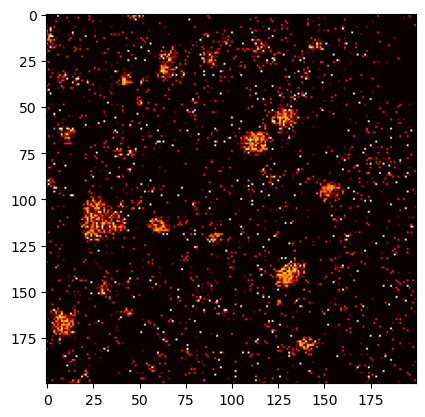

In [38]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image=mpimg.imread("catalyst.png")
a=plt.imshow(image,cmap="hot")

print(f"Image dimensions: {image.shape}")

2. Plot the distribution of the values in the numpy array representing the image (Hint: you need to flatten the array first). Note that the values in the numpy array are between 0 and 1 for png images representing the levels. (1 point)

In [39]:
image

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.12941177, 0.        , 0.        , ..., 0.15294118, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.2901961 ],
       [0.1764706 , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(200, 200), dtype=float32)

In [40]:
import numpy as np

# Flatten the image to a 1D array
flattened_image = image.flatten()

# Check the first few values
print(f"First 10 pixel values: {flattened_image[:10]}")
print(f"Total number of pixels: {len(flattened_image)}")

First 10 pixel values: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Total number of pixels: 40000


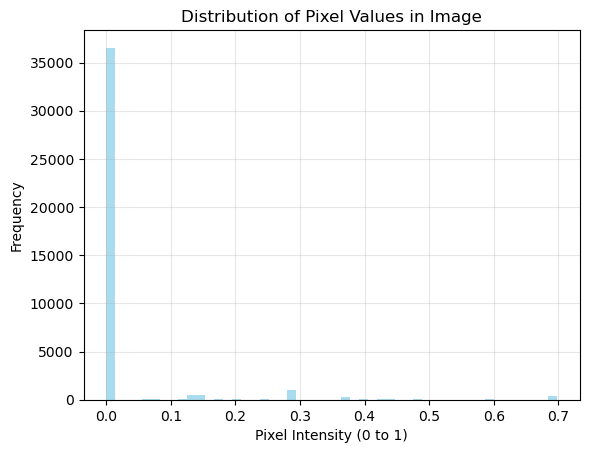

In [41]:
# Plot the histogram
plt.hist(flattened_image, bins=50, color='skyblue', alpha=0.7)
plt.title("Distribution of Pixel Values in Image")
plt.xlabel("Pixel Intensity (0 to 1)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

3. Measured images has a variety of levels. Sometimes, we want to label each pixel at pre-specified levels, e.g., 0 representing the background, and fixed values representing certain features. This is known as vector quantization. Here, we will quantize the image using K-means. We know for a fact that there are two elements (Pd and Ru) in the system. Using K-means, quantize the image such that there are three levels: 0 = background, 1 and 2 = Pd or Ru. Ensure that 0 corresponds to the background (this should be the cluster with the largest number of data points) and non-zero levels correspond to the elements. Plot the quantized image (Hint: you may need to reshape your predicted array back to the original image dimensions), which should look like a slightly modified version of the image in Q4.1. (6 points)

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

pixel_values_for_kmeans=flattened_image.reshape(-1,1)
#Initiate K-Means
kmeans_quant=KMeans(n_clusters=3, random_state=42,n_init="auto")

#Fit K-Means and get the cluster label
initial_kmeans_labels=kmeans_quant.fit_predict(pixel_values_for_kmeans)
cluster_centers_intensity=kmeans_quant.cluster_centers_

print(f"Cluster centers: {cluster_centers_intensity}")
print(f"First 10 K-means labels assigned to pixels: {initial_kmeans_labels[:10]}")

Cluster centers: [[0.00412437]
 [0.3135584 ]
 [0.6839945 ]]
First 10 K-means labels assigned to pixels: [0 0 0 0 0 0 0 0 0 0]


In [43]:
#Identify the background cluster
#Count how many pixels belong to each K-Means label
label_counts=np.bincount(initial_kmeans_labels)
print(f"Number of pixels in each cluster: {label_counts}")

#Assign background label to the cluster with the largest number of pixels
auto_assigned_background_label=np.argmax(label_counts)
print(f"Automatically assigned background label: {auto_assigned_background_label}")

Number of pixels in each cluster: [37726  1832   442]
Automatically assigned background label: 0


In [44]:
#Creat a array to store mapped labels
final_quantized_labels = np.zeros_like(initial_kmeans_labels)

#Identify the K-means labels that were not background
all_possible_kmeans_labels=[0,1,2]
element_kmeans_labels_list=[label for label in all_possible_kmeans_labels if label != auto_assigned_background_label]
print(f"Element K-means labels: {element_kmeans_labels_list}")

Element K-means labels: [1, 2]


In [45]:
#Map the labels:
final_quantized_labels[initial_kmeans_labels==auto_assigned_background_label]=0

intensity_element1=cluster_centers_intensity[element_kmeans_labels_list[0]]
intensity_element2=cluster_centers_intensity[element_kmeans_labels_list[1]]

if intensity_element1 < intensity_element2:
    final_quantized_labels[initial_kmeans_labels==element_kmeans_labels_list[0]]=1
    final_quantized_labels[initial_kmeans_labels==element_kmeans_labels_list[1]]=2
else:
    final_quantized_labels[initial_kmeans_labels==element_kmeans_labels_list[0]]=2
    final_quantized_labels[initial_kmeans_labels==element_kmeans_labels_list[1]]=1

print(f"Final quantized labels: {final_quantized_labels}")
print(f"Counts for remapped labels[0,1,2]: {np.bincount(final_quantized_labels)}")
quantized_image=final_quantized_labels.reshape(image.shape)
print(f"Quantized image shape: {quantized_image.shape}")

Final quantized labels: [0 0 0 ... 0 0 0]
Counts for remapped labels[0,1,2]: [37726  1832   442]
Quantized image shape: (200, 200)


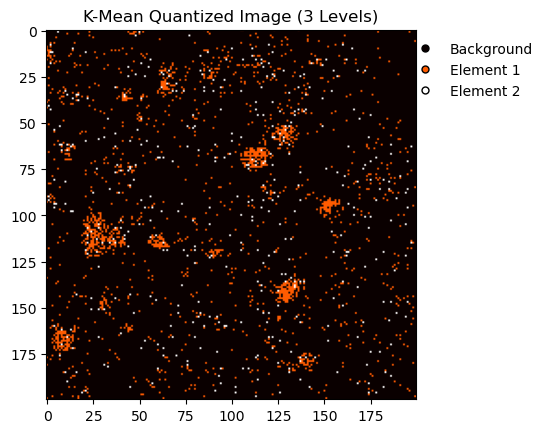

In [59]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Show image
plt.imshow(quantized_image, cmap="hot")

# Create circular legend markers (proxy artists)
legend_elements = [
    Line2D([0], [0], marker='o', color='black', label='Background',
           markerfacecolor=plt.cm.hot(0/2), markersize=5, linestyle='None',),
    Line2D([0], [0], marker='o', color='black', label='Element 1',
           markerfacecolor=plt.cm.hot(1/2), markersize=5, linestyle='None'),
    Line2D([0], [0], marker='o', color='black', label='Element 2',
           markerfacecolor=plt.cm.hot(2/2), markersize=5, linestyle='None'),
]

plt.legend(
    handles=legend_elements,
    loc="upper right",
    fontsize=10,
    frameon=False,
    bbox_to_anchor=(1.35, 1.0)
)

plt.title("K-Mean Quantized Image (3 Levels)")
plt.show()

4. For the purposes of this exercise, we will not attempt to distinguish between different elements. Any value within the numpy array that is > 0 is considered a catalyst particle. Use K-means clustering to identify clusters of metal particles (you will need to figure out what a good value of K is). Hint: the way to do this is to consider the 2D coordinates of non-zero data points and use them in your K-Means fitting. An example is shown in your lecture notebooks on unsupervised learning. After you have obtained your cluster labels, you will need to remap your coordinates-label pairs into pixel values. Plot your clustered image, ensuring that each cluster has a different color. Comment on how you chose your value of K. (10 points)

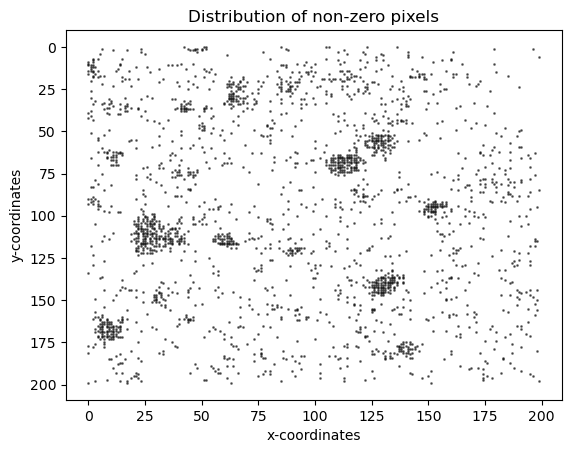

In [48]:
#extract the coordinates of non-zero pixels
coords=np.column_stack(np.nonzero(quantized_image>0))

#Plot the points to get a sense of particle distribution
plt.scatter(coords[:,1], coords[:,0], s=1,alpha=0.5,color="black")
plt.gca().invert_yaxis()
plt.title("Distribution of non-zero pixels")
plt.ylabel("y-coordinates")
plt.xlabel("x-coordinates")
plt.show()



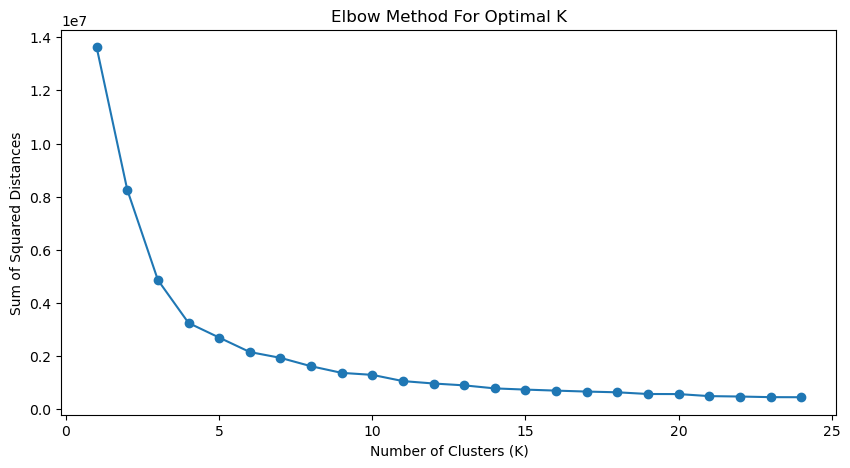

In [49]:
#Determine the optimal K using elbow method
#Caucluate the sum of squared distances for differet values of K
sse=[]
ks=range(1,25)
for k in ks:
    kmeans=KMeans(n_clusters=k)
    kmeans.fit(coords)
    sse.append(kmeans.inertia_)

#Plot the elbow curve
plt.figure(figsize=(10,5))
plt.plot(ks, sse, "o-")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Sum of Squared Distances")
plt.title("Elbow Method For Optimal K")
plt.show()

Trying K=4


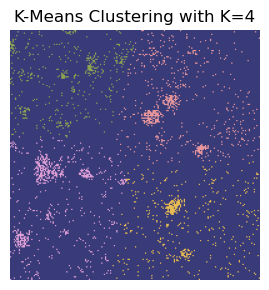

Trying K=5


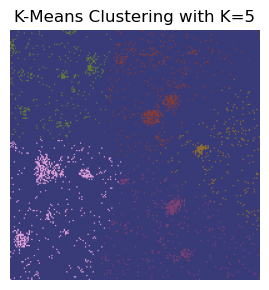

Trying K=6


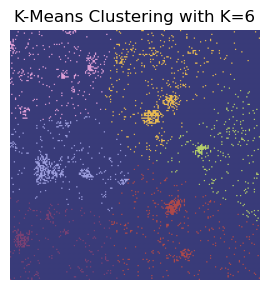

Trying K=7


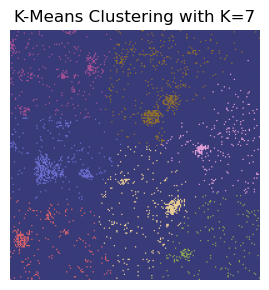

Trying K=8


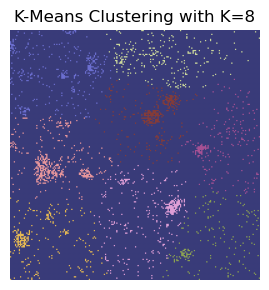

Trying K=9


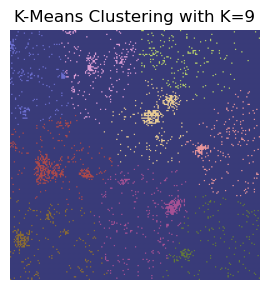

Trying K=10


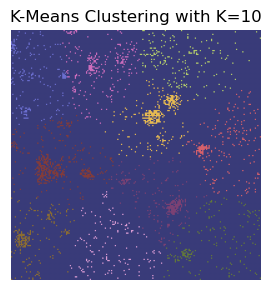

Trying K=11


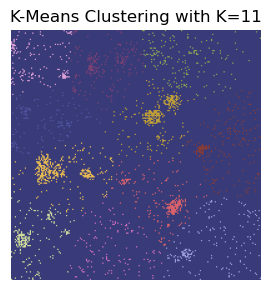

Trying K=12


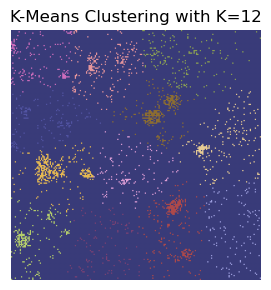

In [81]:
#Apply K-means Clustering with a range of k
k_values_to_try=range(4,13)

for k in k_values_to_try:
    print(f"Trying K={k}")
    kmeans=KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(coords)
    labels=kmeans.labels_
    clustered_image=np.zeros_like(quantized_image)
    for i, coord in enumerate(coords):
        clustered_image[coord[0], coord[1]]=labels[i]+1

    plt.figure(figsize=(5,3))
    plt.imshow(clustered_image, cmap="tab20b")
    plt.title(f"K-Means Clustering with K={k}")
    plt.axis("off")
    plt.tight_layout()
    
    plt.show()



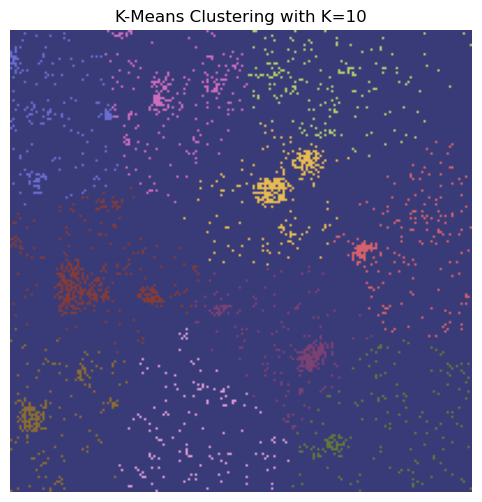

In [62]:
#Apply K-means Clustering with the optimal K
k_chosen=10
kmeans=KMeans(n_clusters=k_chosen, random_state=42, n_init="auto")
kmeans.fit(coords)
labels=kmeans.labels_

#Create a blank image to store the clusters
clustered_image=np.zeros_like(quantized_image)

#Assign the cluster labels to the original image shape
for i, coord in enumerate(coords):
    clustered_image[coord[0], coord[1]]=labels[i]+1

#Plot the clustered image
plt.figure(figsize=(10,6))
plt.imshow(clustered_image, cmap="tab20b")
plt.title(f"K-Means Clustering with K={kmeans.n_clusters}")
plt.axis("off")
plt.show()

Based on the Elbow Method plot, the sum of squared distances decreases sharply until K=4. After K=4, the rate of decrease slows down. A noticeable "elbow" or bend in the curve appears around K=7 or K=8, after which the decrease in inertia for each additional cluster becomes smaller. If we prefer fewer, broader clusters, K= 5 or 6 could be considered, as this is where the initial very steep decline starts to transition. If we need more granular clusters and the smaller decrease in inertia are still meaningful for specific problem (perhaps for separating smaller, distinct particle groups), we might also consider a K up to 10-12. However, the justification from the elbow plot alone becomes weaker as K increases here.
In our case, based on the elbow plot and also visual inspection for the small particle clustering, K>=10 seems provide a good balance between model complexity and its ability to explain the variance in the data. Therefore, we choose k=10 as our optimal k values.

5. Finally, we will use a density-based clustering method called DBSCAN. Similar to part 4, any value in the numpy array that is > 0 is considered a catalyst particle. Use DBSCAN clustering to distinguish identify clusters of metal particles (you will need to figure out what a good value of eps is). Plot your clustered image, ensuring that each cluster has a different color. Comment on how you chose your value of eps. (10 points)


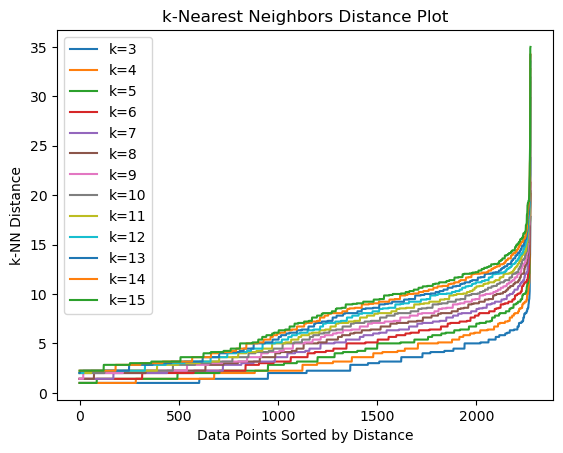

In [52]:
#Ideal starting point for k is 3 to 15
#determine the optimal eps using k-distance plot
from sklearn.neighbors import NearestNeighbors

#compute the k-nearest neighbors 
for k in range (3,16):
    neighbors=NearestNeighbors(n_neighbors=k)
    neighbors_fit=neighbors.fit(coords)
    distances,indices=neighbors_fit.kneighbors(coords)
    distances=np.sort(distances[:, -1])
    plt.plot(distances, label=f"k={k}")

plt.title("k-Nearest Neighbors Distance Plot")
plt.xlabel("Data Points Sorted by Distance")
plt.ylabel("k-NN Distance")
plt.legend()

Select ideal min_samples value ("k" for "k-nearst neighbors"): For 2D data, a common guideline is starting with D+1 which is 3. And for practical purposes, min_samples in the range of 3 to 15 often works well. In our case, K from 1 to 2 might be too sensitive to noise or lead to too many small culsters. K from 16 to 19 maybe to large to cause smaller, distinct clusters to be missed or merged. In our case, a k value in the middle like k=7 or 10 maybe a good starting points to analyze. I will use k=3,7,10,15 to run k-nearest neighbors again to determine best eps value.

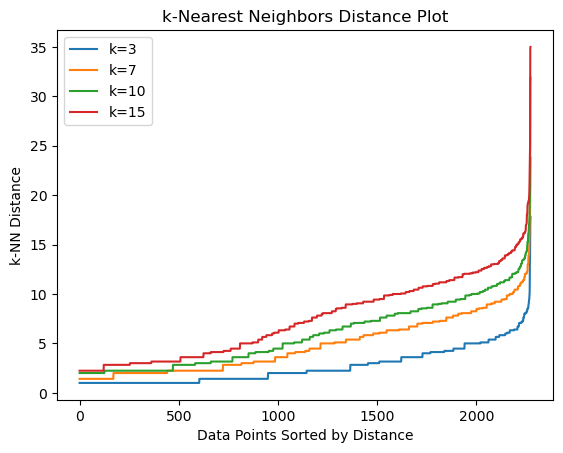

In [82]:
#Ideal starting point for k is 3 to 15
#determine the optimal eps using k-distance plot
from sklearn.neighbors import NearestNeighbors

#compute the k-nearest neighbors 
for k in [3,7,10,15]:
    neighbors=NearestNeighbors(n_neighbors=k)
    neighbors_fit=neighbors.fit(coords)
    distances,indices=neighbors_fit.kneighbors(coords)
    distances=np.sort(distances[:, -1])
    plt.plot(distances, label=f"k={k}")

plt.title("k-Nearest Neighbors Distance Plot")
plt.xlabel("Data Points Sorted by Distance")
plt.ylabel("k-NN Distance")
plt.legend()

We are looking for the "elbow" point on these lines. This is where the rate of increase in k-NN distance changes from relatively slow to significantly faster. The y-value at this elbow is our candidate for eps. The very sharp rise at the far right end of curves usualy represents distances to very isolated points(outliers) and is generally past the optimal eps value we can pick. 
For example, for k=7, the first 500 data points, the k-NN distnace is quite low and flat (around 2-2.5). From x=500 to 1750, the distance steadily increases. Around x=1750 to 2000, the slope of the blue line seems to get noticeably steeper. We can try range from 3 to 8. Similarly, for k=10, the ideal eps range from 5 to 10. We will experiment them to see which combination works better.

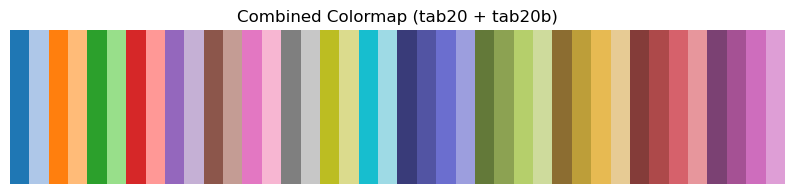

In [54]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Extract colors from tab20 and tab20b
tab20_colors = plt.get_cmap("tab20").colors
tab20b_colors = plt.get_cmap("tab20b").colors

# Combine colors without repetition
combined_colors = list(tab20_colors) + list(tab20b_colors)

# Ensure unique colors by converting to a set and back to a list
unique_colors = list(dict.fromkeys(combined_colors))

# Create a new colormap
combined_cmap = ListedColormap(unique_colors)

# Test the new colormap with a sample plot
plt.figure(figsize=(10, 2))
plt.imshow([list(range(len(unique_colors)))], aspect='auto', cmap=combined_cmap)
plt.title("Combined Colormap (tab20 + tab20b)")
plt.axis("off")
plt.show()

Trying eps=1
Number of clusters: 90


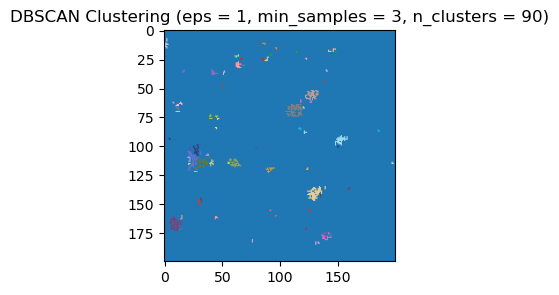

Trying eps=2
Number of clusters: 101


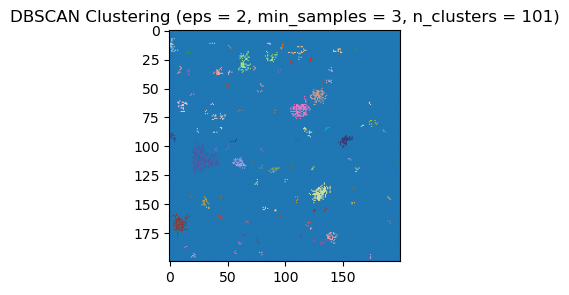

Trying eps=3
Number of clusters: 129


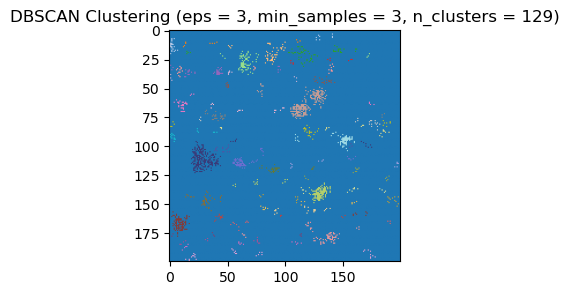

Trying eps=4
Number of clusters: 122


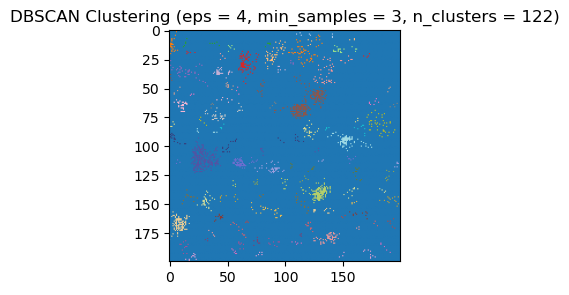

Trying eps=5
Number of clusters: 87


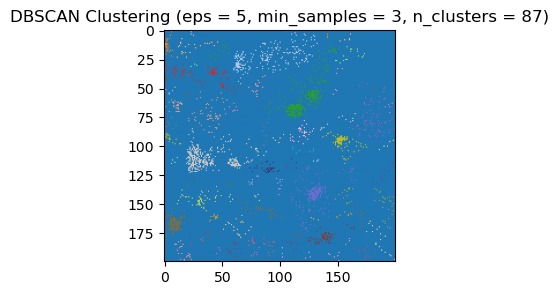

In [90]:

#Apply DBSCAN with the optimal eps
from sklearn.cluster import DBSCAN

#set the eps based on k-distance plot observation
min_samples =3

for eps in [1,2,3,4,5]:
    print(f"Trying eps={eps}")
    dbscan=DBSCAN(eps=eps, min_samples=min_samples)
    dbscan_labels=dbscan.fit_predict(coords)

    #Number of clusters (excluding noise labeled as -1)
    n_clusters=len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    print(f"Number of clusters: {n_clusters}")
    #Assign cluster labels to image and visualize
    #Create a blank image to store the clusters
    dbscan_image=np.zeros_like(quantized_image)

    #Assign the cluster labels to the original image shape
    for i, coord in enumerate(coords):
        dbscan_image[coord[0], coord[1]]=dbscan_labels[i]+1

    #Plot the clustered image
    plt.figure(figsize=(5,3))
    plt.imshow(dbscan_image, cmap=combined_cmap)
    plt.title(f"DBSCAN Clustering (eps = {eps}, min_samples = {min_samples}, n_clusters = {n_clusters})")
    plt.show()



Trying eps=3
Number of clusters: 30


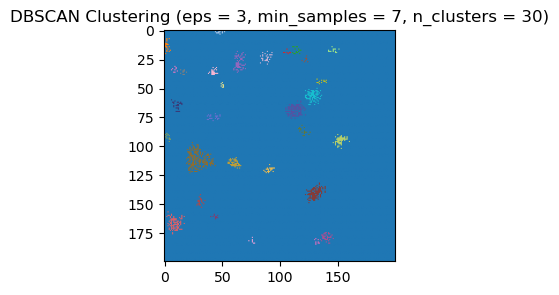

Trying eps=4
Number of clusters: 38


<Figure size 640x480 with 0 Axes>

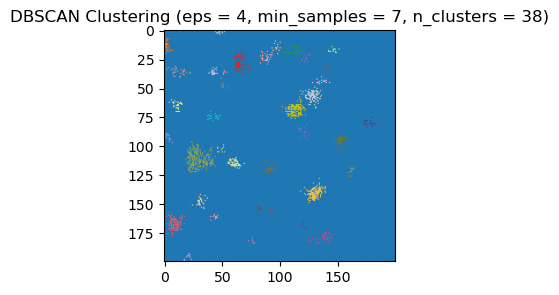

Trying eps=5
Number of clusters: 47


<Figure size 640x480 with 0 Axes>

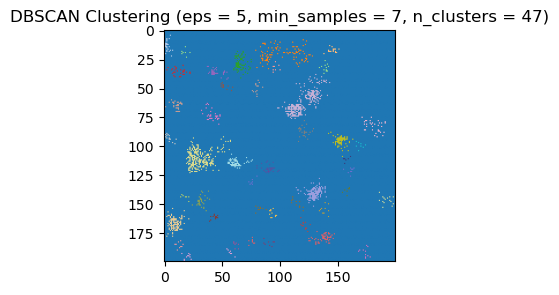

Trying eps=6
Number of clusters: 48


<Figure size 640x480 with 0 Axes>

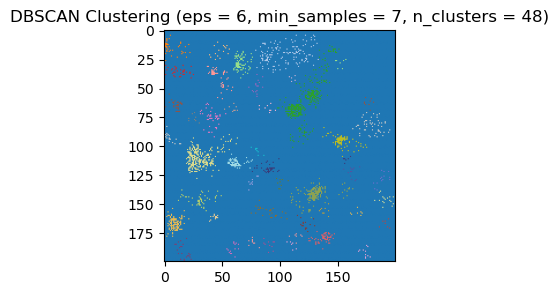

Trying eps=7
Number of clusters: 27


<Figure size 640x480 with 0 Axes>

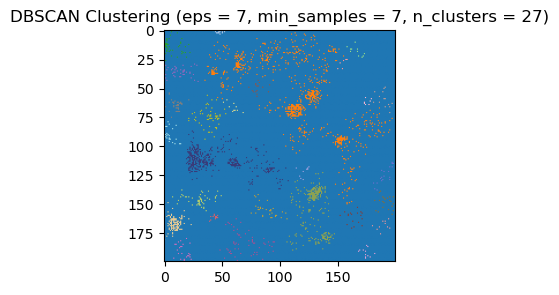

Trying eps=8
Number of clusters: 9


<Figure size 640x480 with 0 Axes>

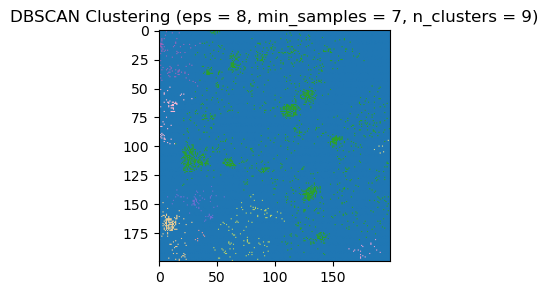

<Figure size 640x480 with 0 Axes>

In [91]:

#Apply DBSCAN with the optimal eps
from sklearn.cluster import DBSCAN

#set the eps based on k-distance plot observation
min_samples =7

for eps in [3,4,5,6,7,8]:
    print(f"Trying eps={eps}")
    dbscan=DBSCAN(eps=eps, min_samples=min_samples)
    dbscan_labels=dbscan.fit_predict(coords)

    #Number of clusters (excluding noise labeled as -1)
    n_clusters=len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    print(f"Number of clusters: {n_clusters}")
    #Assign cluster labels to image and visualize
    #Create a blank image to store the clusters
    dbscan_image=np.zeros_like(quantized_image)

    #Assign the cluster labels to the original image shape
    for i, coord in enumerate(coords):
        dbscan_image[coord[0], coord[1]]=dbscan_labels[i]+1

    #Plot the clustered image
    plt.figure(figsize=(5,3))
    plt.imshow(dbscan_image, cmap=combined_cmap)
    plt.title(f"DBSCAN Clustering (eps = {eps}, min_samples = {min_samples}, n_clusters = {n_clusters})")
    plt.show()
    plt.tight_layout()

Trying eps=5
Number of clusters: 30


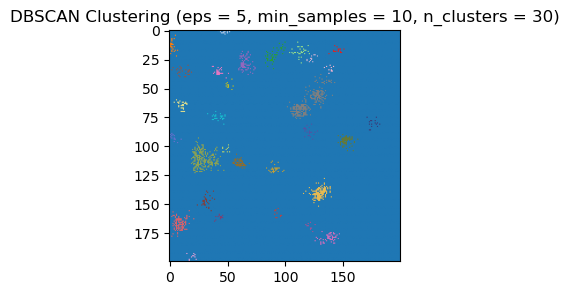

Trying eps=6
Number of clusters: 31


<Figure size 640x480 with 0 Axes>

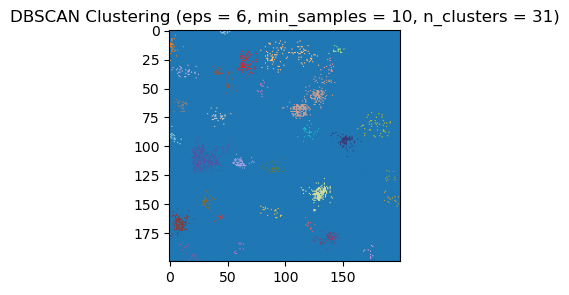

Trying eps=7
Number of clusters: 33


<Figure size 640x480 with 0 Axes>

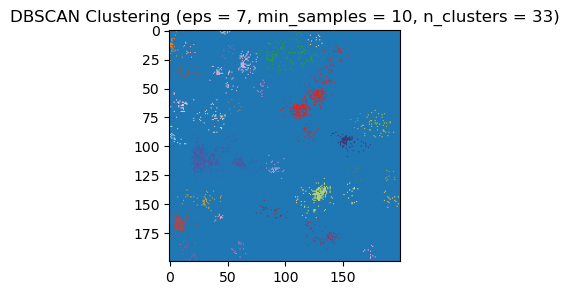

Trying eps=8
Number of clusters: 22


<Figure size 640x480 with 0 Axes>

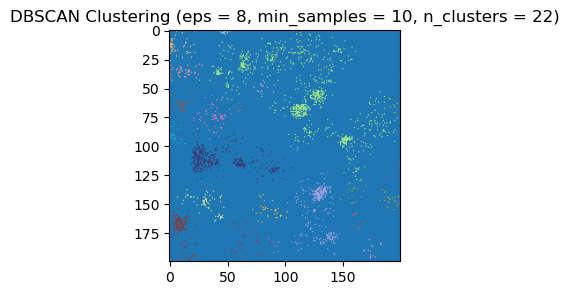

Trying eps=9
Number of clusters: 10


<Figure size 640x480 with 0 Axes>

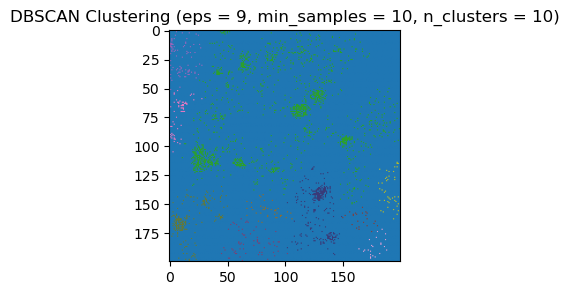

Trying eps=10
Number of clusters: 1


<Figure size 640x480 with 0 Axes>

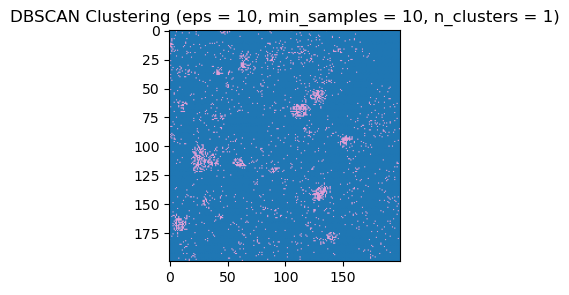

<Figure size 640x480 with 0 Axes>

In [92]:

#Apply DBSCAN with the optimal eps
from sklearn.cluster import DBSCAN

#set the eps based on k-distance plot observation
min_samples =10

for eps in [5,6,7,8,9,10]:
    print(f"Trying eps={eps}")
    dbscan=DBSCAN(eps=eps, min_samples=min_samples)
    dbscan_labels=dbscan.fit_predict(coords)

    #Number of clusters (excluding noise labeled as -1)
    n_clusters=len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    print(f"Number of clusters: {n_clusters}")
    #Assign cluster labels to image and visualize
    #Create a blank image to store the clusters
    dbscan_image=np.zeros_like(quantized_image)

    #Assign the cluster labels to the original image shape
    for i, coord in enumerate(coords):
        dbscan_image[coord[0], coord[1]]=dbscan_labels[i]+1

    #Plot the clustered image
    plt.figure(figsize=(5,3))
    plt.imshow(dbscan_image, cmap=combined_cmap)
    plt.title(f"DBSCAN Clustering (eps = {eps}, min_samples = {min_samples}, n_clusters = {n_clusters})")
    plt.show()
    plt.tight_layout()

Trying eps=3
Number of clusters: 10


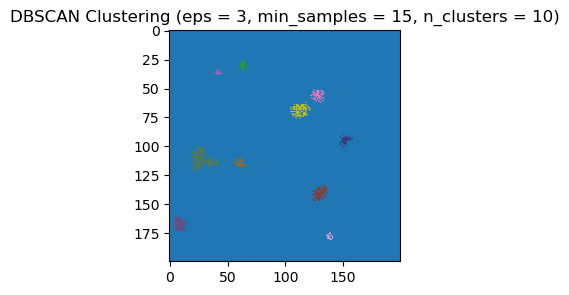

Trying eps=4
Number of clusters: 15


<Figure size 640x480 with 0 Axes>

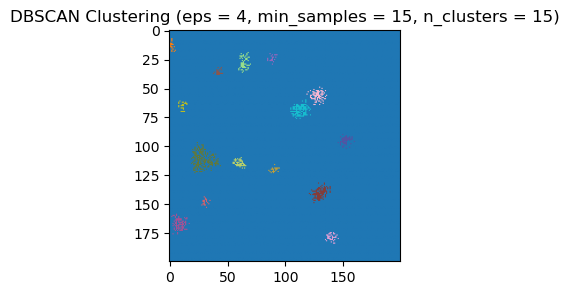

Trying eps=5
Number of clusters: 18


<Figure size 640x480 with 0 Axes>

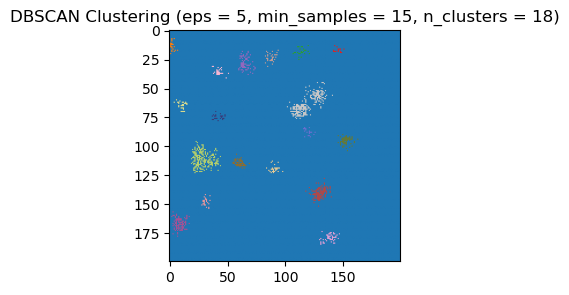

Trying eps=6
Number of clusters: 20


<Figure size 640x480 with 0 Axes>

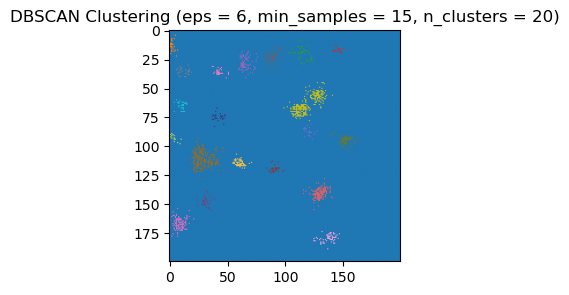

Trying eps=7
Number of clusters: 23


<Figure size 640x480 with 0 Axes>

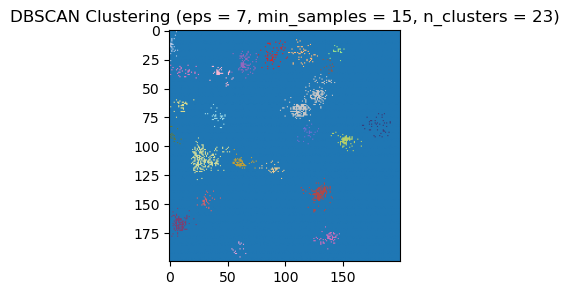

Trying eps=8
Number of clusters: 23


<Figure size 640x480 with 0 Axes>

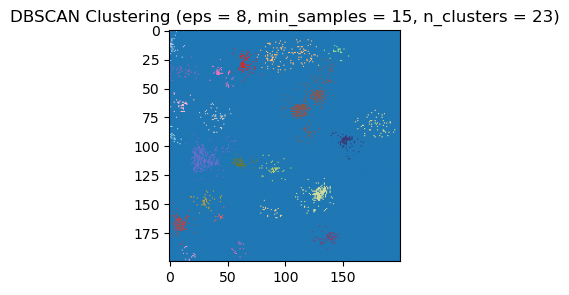

Trying eps=9
Number of clusters: 17


<Figure size 640x480 with 0 Axes>

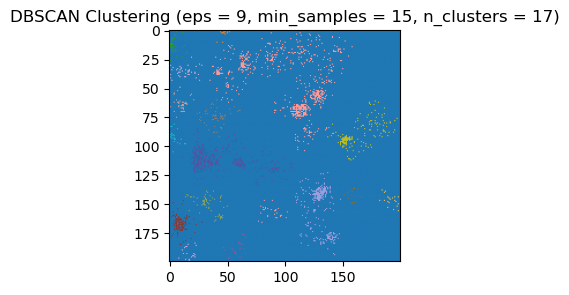

Trying eps=10
Number of clusters: 13


<Figure size 640x480 with 0 Axes>

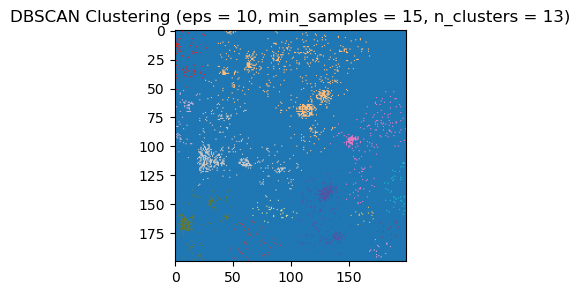

<Figure size 640x480 with 0 Axes>

In [93]:

#Apply DBSCAN with the optimal eps
from sklearn.cluster import DBSCAN

#set the eps based on k-distance plot observation
min_samples =15

for eps in [3,4,5,6,7,8,9,10]:
    print(f"Trying eps={eps}")
    dbscan=DBSCAN(eps=eps, min_samples=min_samples)
    dbscan_labels=dbscan.fit_predict(coords)

    #Number of clusters (excluding noise labeled as -1)
    n_clusters=len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    print(f"Number of clusters: {n_clusters}")
    #Assign cluster labels to image and visualize
    #Create a blank image to store the clusters
    dbscan_image=np.zeros_like(quantized_image)

    #Assign the cluster labels to the original image shape
    for i, coord in enumerate(coords):
        dbscan_image[coord[0], coord[1]]=dbscan_labels[i]+1

    #Plot the clustered image
    plt.figure(figsize=(5,3))
    plt.imshow(dbscan_image, cmap=combined_cmap)
    plt.title(f"DBSCAN Clustering (eps = {eps}, min_samples = {min_samples}, n_clusters = {n_clusters})")
    plt.show()
    plt.tight_layout()

- As we can see based on the result, in DBSCAN, the choice of its two main parameters, eps and min_samples can significantly influences the clustering outcome. The eps parameter defines the radius of the neighborhood around a data point, while min_samples specifies the minimum number of data points required within that eps-neighborhood for a point to be considered a core point (and thus part of a dense region)
- Before determining eps, a value for min_samples must be selected. The choice of min_samples often depends on the dimensionality of the data and the nature of the clusters expected.For 2-dimensional data, such as our particle coordinates (x, y), a common heuristic is min_samples >= D+1 (i.e., min_samples >= 3). In practice, slightly larger values (e.g., 5 to 15 for 2D spatial data) are often chosen to ensure more robust cluster formation and better noise identification. This is because a larger min_samples requires a more substantial group of points to define a dense region.For this analysis, min_samples was set to 3,7,10,15 to balance sensitivity to smaller particle groups with robustness against noise. This chosen min_samples value is then used in the primary method for estimating eps.
- Then we use k-distance plot method for estimating good eps value. Based on the k-distance plot, we choose a range of eps to try based on different k(min_samples). Visual inspection of the resulting clustered images for eps=3 min_samples=7 and eps=4 min_samples=15 showed a reasonable separation of particle groups with an acceptable level of noise identification, confirming it as a suitable choise. I will plot this two below as a reference.

Trying eps=4
Number of clusters: 15


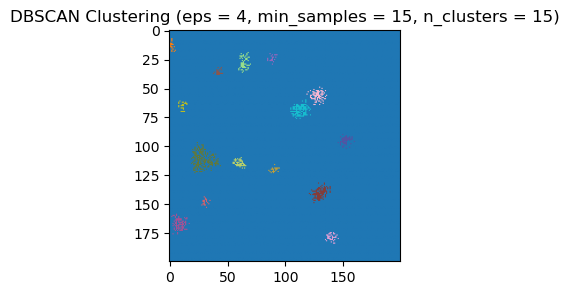

<Figure size 640x480 with 0 Axes>

In [94]:

#Apply DBSCAN with the optimal eps
from sklearn.cluster import DBSCAN

#set the eps based on k-distance plot observation
min_samples =15
eps=4
print(f"Trying eps={eps}")
dbscan=DBSCAN(eps=eps, min_samples=min_samples)
dbscan_labels=dbscan.fit_predict(coords)

#Number of clusters (excluding noise labeled as -1)
n_clusters=len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print(f"Number of clusters: {n_clusters}")
#Assign cluster labels to image and visualize
#Create a blank image to store the clusters
dbscan_image=np.zeros_like(quantized_image)

#Assign the cluster labels to the original image shape
for i, coord in enumerate(coords):
    dbscan_image[coord[0], coord[1]]=dbscan_labels[i]+1

#Plot the clustered image
plt.figure(figsize=(5,3))
plt.imshow(dbscan_image, cmap=combined_cmap)
plt.title(f"DBSCAN Clustering (eps = {eps}, min_samples = {min_samples}, n_clusters = {n_clusters})")
plt.show()
plt.tight_layout()

Trying eps=3
Number of clusters: 30


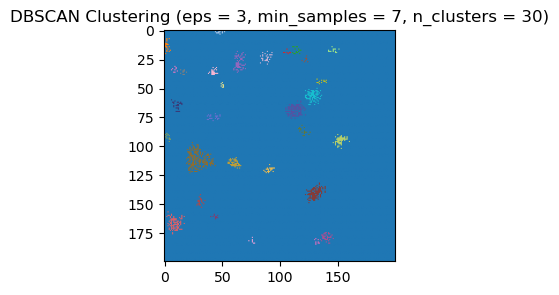

<Figure size 640x480 with 0 Axes>

In [95]:

#Apply DBSCAN with the optimal eps
from sklearn.cluster import DBSCAN

#set the eps based on k-distance plot observation
min_samples =7
eps=3
print(f"Trying eps={eps}")
dbscan=DBSCAN(eps=eps, min_samples=min_samples)
dbscan_labels=dbscan.fit_predict(coords)

#Number of clusters (excluding noise labeled as -1)
n_clusters=len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print(f"Number of clusters: {n_clusters}")
#Assign cluster labels to image and visualize
#Create a blank image to store the clusters
dbscan_image=np.zeros_like(quantized_image)

#Assign the cluster labels to the original image shape
for i, coord in enumerate(coords):
    dbscan_image[coord[0], coord[1]]=dbscan_labels[i]+1

#Plot the clustered image
plt.figure(figsize=(5,3))
plt.imshow(dbscan_image, cmap=combined_cmap)
plt.title(f"DBSCAN Clustering (eps = {eps}, min_samples = {min_samples}, n_clusters = {n_clusters})")
plt.show()
plt.tight_layout()

6. Discuss on the differences between the K-means and DBSCAN results, and which method is more appropriate for the purpose we are using it for. (2 points)


In this exercise, we applied both K-means and DBSCAN clustering to segment catalyst particles in the image. K-means, which partitions data into a predetermined number of spherical clusters based on centroid distances, effectively identifies clusters when the data is uniformly distributed and clusters are similarly sized. However, it is less effective in identifying arbitrarily shaped clusters and can incorrectly assign noise points to clusters. In contrast, DBSCAN leverages density-based clustering, allowing it to detect clusters of varying shapes and sizes and effectively separate noise points (background pixels). Given that the catalyst particles are irregularly shaped and vary in density, DBSCAN is more appropriate for this task, as it can accurately distinguish densely packed particle clusters from sparse noise areas without requiring a predefined number of clusters. Thus, DBSCAN provides a more robust approach for this dataset, aligning well with the structural characteristics of the particles.